# Obesity Risk Factor Analysis & Custom Softmax Regression Implementation

Our dataset relates to how the habits of different people affect their level of obesity. The tracked features include:
| Feature Name                          | Alias          | Description |
|--------------------------------------|----------------|-------------|
| Gender                               | Gender         | Gender of the individual |
| Age                                  | Age            | Age of the individual |
| Height                               | Height         | Height of the individual |
| Weight                               | Weight         | Weight of the individual |
| family_history_with_overweight       | Family History | Has a family member suffered or suffers from overweight? |
| FAVC                                 | High caloric   | Do you eat high caloric food frequently? |
| FCVC                                 | Vegetables     | Do you usually eat vegetables in your meals? |
| NCP                                  | Meals          | How many main meals do you have daily? |
| CAEC                                 | Snacks         | Do you eat any food between meals? |
| SMOKE                                | Smoking        | Do you smoke? |
| CH2O                                 | Water          | How much water do you drink daily? |
| SCC                                  | Monitoring     | Do you monitor the calories you eat daily? |
| FAF                                  | Activity       | How often do you have physical activity? |
| TUE                                  | Devices        | How much time do you use technological devices such as cell phone, videogames, television, computer and others? |
| CALC                                 | Alcohol        | How often do you drink alcohol? |
| MTRANS                               | Transport      | Which transportation do you usually use? |
| NObeyesdad                           | Obesity        | Obesity level (Target variable) |

## Correlation matrix of the dataset

<img src="plots/correlation_matrix.png" alt="Correlation Matrix" width="600"/>

The correlations between features are mostly expected, however, some warrant further examination:
- Very strong correlation between family history and both obesity and weight
- Fairly strong negative correlation between self reported amount of food eaten between meals and obesity
- Positive correlation between reporting of eating vegetables and obesity

## Obesity level distribution in sample

<img src="plots/histogram.png" alt="Obesity distribution in sample" width="400"/>

The distribution of different levels of obesity in our sample is within reason - the number of people in each category rises with the level of obesity, but the difference is not so large so as to substantially influence the results

## Chosen mode of transport based on gender

<img src="plots/histogram_with_hue.png" alt="Chosen mode of transport based on gender" width="400"/>

As we can see, in out sample, most people's preferred mode of transport is public transit or automobile - the sample for people using any other mode of transportation is tiny. Women tend to choose public transit more often than men

## Distribution of weight in each obesity class

<img src="plots/box_plot.png" alt="Distribution of weight in each obesity class" width="400"/>

For both sexes, we see that the largest variation in weights falls into the normal weight category – this suggests that the normal weight scale at diagnosis is the largest. The most abnormal point is one of the few men in the data set who fall into the type 3 obesity category – he weighs a whopping 180kg. The median weight of men is consistently lower than that of women, which is in line with predictions

## Weight vs height

<img src="plots/linreg.png" alt="Weight vs height" width="400"/>

From this graph, it turns out that women's weight increases much more rapidly with height than men's. Women tend to weigh more than men of the same height. The linear regression is within the standard error, suggesting a near-linear correlation between the two factors

## Effect of monitoring calorie intake on obesity

<img src="plots/violin_plot.png" alt="Effect of monitoring calorie intake on obesity" width="400"/>

This graph suggests that people who control their calorie intake tend to be less obese than those who don’t. People with high levels of obesity almost never control their calorie intake.

## Principal component analysis

<img src="plots/pca.png" alt="Principal component analysis" width="400"/>

After the principal components analysis for two dimensions, we see that the groups of people with obesity – categories 4, 5 and 6, are in one group – this means that the whole set has very similar characteristics. This effect is less visible for the other categories – this suggests that people without obesity have much more diverse characteristics.

# Machine learning

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt
from sklearn.base import TransformerMixin, BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import check_random_state
from torch.utils.data import TensorDataset, DataLoader
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")

def sigmoid(z):
    sigmoid_val = 1 / (1 + np.exp( - z))
    epsilon = 1e-15
    return np.clip(sigmoid_val, epsilon, 1 - epsilon)

np.random.seed(42)

In [2]:
results_classifiers = []

# pd.DataFrame(columns=['Name', 'Parameters', 'Training', 'Validation', 'Testing'])

In [3]:
results_regressors = []

# Data import
Firstly, we'll be downloading the data to analyze. On the first run, the data is downloaded from a repository and saved in a file for subsequent use.

In [4]:
features_filename = "saved_data/features.csv"
targets_filename = "saved_data/targets.csv"

def fetch_data():
    if os.path.isfile(features_filename) and os.path.isfile(targets_filename):
        print("Loading data from files...")
    else:
        print("File not found, downloading...")
        fetched_data = fetch_ucirepo(id=544)
        features = fetched_data.data.features
        targets = fetched_data.data.targets
        if not os.path.isdir("saved_data"):
            os.mkdir("saved_data")
        features.to_csv(features_filename, index=False)
        targets.to_csv(targets_filename, index=False)
    X = pd.read_csv(features_filename)
    y = pd.read_csv(targets_filename)
    return X,y

obesity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

X, y = fetch_data()
y['NObeyesdad'] = pd.Categorical(y['NObeyesdad'], categories = obesity_order, ordered = True)
print("\nData:\n")
display(X)
print("\nTargets:\n")
display(y)

Loading data from files...

Data:



,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation



Targets:



,NObeyesdad
0,Normal_Weight
1,Normal_Weight
2,Normal_Weight
3,Overweight_Level_I
4,Overweight_Level_II
...,...
2106,Obesity_Type_III
2107,Obesity_Type_III
2108,Obesity_Type_III
2109,Obesity_Type_III


In [5]:
X_dummy, X_test, y_dummy, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipelines
A pipeline chains multiple data processing steps into a single unit, ensuring consistent transformations for both training and test data. It simplifies workflows by:
- Automatically handling fitting/transforming in the correct order
- Preventing data leakage (e.g., test data never influences preprocessing)
- Enabling hyperparameter tuning across all steps

While scikit - learn provides common transformers (e.g., StandardScaler), for this task we'll implement some custom transformers to help transform the data into an easier to understand form.

###
This transformer takes pairs of sets as arguments in the constructor, which represent sets of values to be treated as True and False respectively. When transform is called, it loops through each pair for each column, and if for a specific pair each unique value in the column belongs to either the true or false set, it maps the column to boolean values based on belonging to the sets.

In [6]:
class BooleanConverter(BaseEstimator, TransformerMixin):
    def __init__(self, true_false_set_pairs):
        self.column_mappings_ = None
        self.true_false_set_pairs = true_false_set_pairs or []

    def fit(self, X, y=None):
        self.column_mappings_ = {}
        for column in X.columns:
            values = set(X[column].dropna())
            for true_false_set in self.true_false_set_pairs:
                true_set, false_set = true_false_set
                if values.issubset(true_set | false_set):
                    self.column_mappings_.update({column: (true_set, false_set)})
                    break
            if column not in self.column_mappings_:
                raise ValueError(f"No mapping found for column {column}")
        return self

    def transform(self, X):
        if not self.column_mappings_:
            raise ValueError("The encoder has not been fitted yet.")
        X = X.copy()
        for column, (true_set, false_set) in self.column_mappings_.items():
            X[column] = X[column].map(lambda x: x in true_set)
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features

### Categorical Converter
This transformer takes any number of iterables as parameters and converts all columns for which the set of unique values in it are a subset one of them into categorical columns, while making them ordered if the iterable was ordered

In [7]:
class CategoricalConverter(BaseEstimator, TransformerMixin):
    def __init__(self, category_list, ordered):
        self.column_mappings_ = None
        self.category_list = category_list or []
        self.ordered = ordered

    def fit(self, X, y=None):
        self.column_mappings_ = {}
        for column in X.columns:
            values = set(X[column].dropna())
            for category in self.category_list:
                if values.issubset(category):
                    self.column_mappings_.update({column: category})
                    break
            if column not in self.column_mappings_:
                raise ValueError(f"No mapping found for column {column}")
        return self

    def transform(self, X):
        if not self.column_mappings_:
            raise ValueError("The encoder has not been fitted yet.")
        X = X.copy()
        for column, category in self.column_mappings_.items():
            values = set(X[column].dropna())
            if not values.issubset(set(category)):
                warnings.warn(f"Warning: column {column} contains unsupported categories: {values - category}")
            X[column] = pd.Categorical(X[column], category, ordered = True)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(input_features)

### Rigid ordinal encoder
A redesigned version of ordinal encoder, which assumes the column is a pandas category column, and uses the categories defined in that column for enumeration

In [8]:
class RigidOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.column_mappings_ = None
        self.inverse_mappings_ = None

    def fit(self, X, y=None):
        if not all(isinstance(X[column].dtype, pd.CategoricalDtype) for column in X.columns):
            raise ValueError("All columns in X must be pandas Categorical dtype.")
        self.column_mappings_ = {
        column: {category: i for i, category in enumerate(X[column].cat.categories)}
        for column in X.columns}
        self.inverse_mappings_ = {
        column: {i : category for i, category in enumerate(X[column].cat.categories)}
        for column in X.columns}
        return self

    def transform(self, X):
        if not self.column_mappings_:
            raise ValueError("The encoder has not been fitted yet.")
        X = X.copy()
        for column, categories in self.column_mappings_.items():
            X[column] = X[column].map(lambda x: categories.get(x))
        return X

    def inverse_transform(self, X):
        if not self.column_mappings_:
            raise ValueError("The encoder has not been fitted yet.")
        X = X.copy()
        for column, categories in self.inverse_mappings_.items():
            X[column] = X[column].map(lambda x: categories.get(x))
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(input_features)

### Column Renamer

This one does not actually transform the values themselves - just replaces the names in get_feature_names_out, for readability

In [9]:
class ColumnRenamer(BaseEstimator, TransformerMixin):
    def __init__(self, dictionary):
        self.dictionary = dictionary

    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns if hasattr(X, 'columns') else [f'x{i}' for i in range(X.shape[1])]
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names_in_)
        X_renamed = X.rename(columns=self.dictionary)
        return X_renamed

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_

        return [self.dictionary.get(name, name) for name in input_features]

renamer = ColumnRenamer({
    'family_history_with_overweight' : 'Family History',
    'FAVC' : 'High caloric',
    'FCVC' : 'Vegetables',
    'NCP' : 'Meals',
    'CAEC' : 'Snacks',
    'SMOKE' : 'Smoking',
    'CH2O' : 'Water',
    'SCC' : 'Monitoring',
    'FAF' : 'Activity',
    'TUE' : 'Devices',
    'CALC' : 'Alcohol',
    'MTRANS' : 'Transport',
    'NObeyesdad' : 'Obesity'
})

# Column transformer
We are going to use a pipeline and ColumnTransformer to preprocess the data before inputting it into our classifiers.

In [10]:
bool_converter = BooleanConverter([({"yes"},{"no"})])


categorical_unordered_converter = CategoricalConverter(
    [["Male","Female"],
    ["Public_Transportation", "Walking", "Automobile", "Bike", "Motorbike"]],
ordered=False)


categorical_ordered_converter = CategoricalConverter(
    [["no", "Sometimes", "Frequently", "Always"]],
    ordered=True
)

def make_column_transformer(numeric, bool, ordered, unordered, scaler, scaler_sparse = 'same'):
    if not scaler_sparse:
        scaler_sparse = FunctionTransformer()
    if scaler_sparse == 'same':
        scaler_sparse = scaler

    numeric_processor = Pipeline([
        ('renamer', renamer),
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', scaler)
    ])
    bool_processor = Pipeline([
        ('renamer', renamer),
        ('converter', bool_converter),
        ('scaler', scaler)
    ])
    ordered_processor = Pipeline([
        ('renamer', renamer),
        ('converter', categorical_ordered_converter),
        ('encoder', RigidOrdinalEncoder()),
        ('scaler', scaler)
    ])
    unordered_processor = Pipeline([
        ('renamer', renamer),
        ('converter', categorical_unordered_converter),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ('scaler', scaler_sparse)
    ])
    return ColumnTransformer([
        ('numeric', numeric_processor, numeric),
        ('boolean', bool_processor, bool),
        ('ordered', ordered_processor, ordered),
        ('unordered', unordered_processor, unordered),
    ])
    
    

numeric_columns = ['Age','Height','Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
bool_columns = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
ordered_columns = ['CAEC', 'CALC']
unordered_columns = ['Gender', 'MTRANS']

preprocessor = make_column_transformer(
    numeric_columns, bool_columns, ordered_columns, unordered_columns,
    StandardScaler(), StandardScaler(with_mean=False)
)

### Model declaration

We'll be using a pipeline with a preprocessor and the model to process and predict data. The train data is split into 2 parts - actual training data used to train the models and validation data which are used to judge the performance while adjusting hyperparameters. The best models (with the best parameters) are saved in a dictionary for future executions. We are going to initialize 5 different classificaltion models and save their results to be compared at a later point

In [11]:
if 'models_info' not in globals():
    models_info = {}

In [12]:
test_fold = np.concatenate([
    np.zeros(len(X_dummy) // 4, dtype=int),       -1 * np.ones(len(X_dummy) - len(X_dummy) // 4, dtype=int)  # train samples
])
X_train = []
y_train = []
X_val = []
y_val = []

presplit = PredefinedSplit(test_fold=test_fold)

for i, (_, row) in enumerate(X_dummy.iterrows()):
    (X_val,X_train)[ - test_fold[i]].append(row)

for i, (_, row) in enumerate(y_dummy.iterrows()):
    (y_val,y_train)[ - test_fold[i]].append(row)

X_train = pd.DataFrame(X_train, columns = X_dummy.columns)
y_train = pd.DataFrame(y_train, columns = y_dummy.columns)
X_val = pd.DataFrame(X_val, columns = X_dummy.columns)
y_val = pd.DataFrame(y_val, columns = y_dummy.columns)


def test_all():
    classifiers = {
        'Random Forest Classifier': {
            'model' : Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', RandomForestClassifier(random_state=42))
            ]),
            'param_grid' : {
                'classifier__n_estimators': [50, 100, 200],
                'classifier__max_depth': [None, 10, 20, 30],
                'classifier__min_samples_split': [2, 5, 10],
                'classifier__min_samples_leaf': [1, 2, 4],
                'classifier__max_features': ['auto', 'sqrt', 'log2'],
                'classifier__bootstrap': [True, False]
            }
        },
    
        'Decision Tree': {
            'model' : Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', DecisionTreeClassifier(random_state=42))
            ]),
            'param_grid': {
                'classifier__criterion': ['gini', 'entropy'],
                'classifier__max_depth': [None, 10, 20, 30, 40, 50],
                'classifier__min_samples_split': [2, 5, 10],
                'classifier__min_samples_leaf': [1, 2, 4],
                'classifier__max_features': [None, 'auto', 'sqrt', 'log2'],
                'classifier__max_leaf_nodes': [None, 10, 20, 30, 40],
                'classifier__min_weight_fraction_leaf': [0.0, 0.01, 0.05]
            }
        },
    
        'SVC Linear' : {
            'model' : Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', SVC(random_state=42))
            ]),
            'param_grid': {
                'classifier__C': [0.1, 1, 10, 100],
                'classifier__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
                'classifier__degree': [2, 3, 4],            'classifier__gamma': ['scale', 0.001, 0.01, 0.1, 1]
            }
        },
    
        'Logistic Regression' : {
            'model' : Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', LogisticRegression(random_state=42, max_iter=1000))
            ]),
            'param_grid': {
                'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
                'classifier__C': [0.01, 0.1, 1, 10, 100],
                'classifier__solver': ['saga', 'lbfgs', 'liblinear', 'newton - cg', 'sag'],
                'classifier__l1_ratio': [0, 0.5, 1]  # Only used if penalty='elasticnet'
            }
        }
    }
    
    for name, info in classifiers.items():
        if name not in models_info:
            grid_search = GridSearchCV(
                estimator= info['model'],
                param_grid= info['param_grid'],
                scoring='accuracy',
                cv=presplit,
                n_jobs= - 1,
                refit=True,
                error_score=0,
                verbose=0
            )
            grid_search.fit(X_dummy, y_dummy)
            models_info.update({
                name : {
                    'base_model' : info['model'],
                    'basic_model' : grid_search.best_estimator_,
                    'param_grid' : info['param_grid'],
                    'classifier' : True
                }
            })
        model = models_info[name]['basic_model']
        result_row = {
            'Name' : name,
            'Parameters' : model.named_steps['classifier'].get_params(),
        }

        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        result_row.update({'Training' : accuracy_score(y_train['NObeyesdad'], y_pred)})
        y_pred = model.predict(X_val)
        result_row.update({'Validation' : accuracy_score(y_val['NObeyesdad'], y_pred)})
        y_pred = model.predict(X_test)
        result_row.update({'Testing' : accuracy_score(y_test['NObeyesdad'], y_pred)})
        results_classifiers.append(result_row)

test_all()

# Linear regression (closed form)

Closed - form linear regression refers to the analytical solution for finding the optimal weights that minimize the mean squared error between the predicted and actual target values. Instead of using iterative optimization methods like gradient descent, it directly computes the weights using a mathematical formula derived from setting the gradient of the cost function to zero. The solution is given by:

$
\mathbf{w} = (\mathbf{X}^\top \mathbf{X})^{ - 1} \mathbf{X}^\top \mathbf{y}
$

where \(\mathbf{X}\) is the input feature matrix (with a column of ones if including an intercept), \(\mathbf{y}\) is the target vector, and \(\mathbf{w}\) is the vector of regression coefficients. This method is efficient for small to medium datasets but can be computationally expensive or unstable when \(\mathbf{X}^\top \mathbf{X}\) is not invertible or very large.

In [13]:
class MyLinearRegression(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.theta_ = None

    def fit(self, X, y):
        X = np.c_[np.ones((X.shape[0], 1)), X]
        self.theta_ = np.linalg.pinv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X):
        X = np.c_[np.ones((X.shape[0], 1)), X]
        return X @ self.theta_

    @property
    def coef_(self):
        return self.theta_[1:]

    @property
    def intercept_(self):
        return self.theta_[0]

For the sake of testing the linear regression algorithm, the target is changed to be weight instead of the classification of obesity level. The preprocessor is also adapted to exclude the target column

In [14]:
new_y_train = X_train['Weight']
new_y_val = X_val['Weight']
new_y_dummy = X_dummy['Weight']
new_y_test = X_test['Weight']

new_X_train = X_train.drop('Weight', axis=1)
new_X_val = X_val.drop('Weight', axis=1)
new_X_dummy = X_dummy.drop('Weight', axis=1)
new_X_test = X_test.drop('Weight', axis=1)

new_numeric = numeric_columns.copy()
new_numeric.remove('Weight')

regression_preprocessor = make_column_transformer(
    new_numeric, bool_columns, ordered_columns, unordered_columns,
    StandardScaler(), StandardScaler(with_mean=False)
)

my_linear_regression = Pipeline([
    ('preprocessor', regression_preprocessor),
    ('regressor', MyLinearRegression())
])

sklearn_linear_regression = Pipeline([
    ('preprocessor', regression_preprocessor),
    ('regressor',  LinearRegression())
])

my_linear_regression.fit(new_X_train, new_y_train)
my_y_pred = my_linear_regression.predict(new_X_test)

sklearn_linear_regression.fit(new_X_train, new_y_train)
sklearn_y_pred = sklearn_linear_regression.predict(new_X_test)

names = list(map(lambda x: x.split('__')[1], my_linear_regression.named_steps['preprocessor'].get_feature_names_out()))
names.append('Intercept')

my_coefficients = list(round(x,3) for x in my_linear_regression.named_steps['regressor'].coef_)
my_coefficients.append(round(my_linear_regression.named_steps['regressor'].intercept_,3))
sklearn_coefficients = list(round(x,3) for x in sklearn_linear_regression.named_steps['regressor'].coef_)
sklearn_coefficients.append(round(sklearn_linear_regression.named_steps['regressor'].intercept_,3))
stats = pd.DataFrame(
    data = zip(names,my_coefficients,sklearn_coefficients),
    columns = ['Variable', 'My Coefficient', 'Sklearn Coefficient']
)
display(stats)

result_row = {
    'Name' : 'Closed form',
    'Parameters': {},
    'Coefficients': list(zip(names, my_coefficients))
}
y_pred = my_linear_regression.predict(new_X_train)
result_row.update({'Training' : mean_squared_error(new_y_train, y_pred)})
y_pred = my_linear_regression.predict(new_X_val)
result_row.update({'Validation' : mean_squared_error(new_y_val, y_pred)})
y_pred = my_linear_regression.predict(new_X_test)
result_row.update({'Testing' : mean_squared_error(new_y_test, y_pred)})
results_regressors.append(result_row)

,Variable,My Coefficient,Sklearn Coefficient
0,Age,6.058,6.058
1,Height,11.534,11.534
2,Vegetables,5.214,5.214
3,Meals,0.625,0.625
4,Water,0.608,0.608
5,Activity,-2.450,-2.450
6,Devices,-0.509,-0.509
7,Family History,8.087,8.087
8,High caloric,1.366,1.366
9,Smoking,-0.469,-0.469


**Handling Collinearity in scikit - learn's Linear Regression**

scikit - learn’s `LinearRegression` uses a numerical solver based on Singular Value Decomposition (SVD) to compute the regression coefficients. This approach helps handle collinearity (high correlation between features) by effectively reducing the impact of nearly linearly dependent features. Instead of directly inverting $\mathbf{X}^\top \mathbf{X}\$, SVD decomposes the feature matrix into components, allowing the solver to ignore or dampen components associated with very small singular values. This prevents unstable or excessively large coefficients caused by multicollinearity, leading to more stable and reliable weight estimates even when features are highly correlated.


## Gradient Descent

Gradient descent is an iterative optimization algorithm used to minimize the cost function of a linear regression model by adjusting the model parameters (weights). In this implementation, at each iteration, the algorithm computes the gradient of the mean squared error with respect to the weights using either the entire dataset (batch gradient descent) or subsets of data (mini - batch gradient descent). The weights are then updated by moving in the direction opposite to the gradient, scaled by a learning rate that controls the step size. The process repeats until the change in weights is smaller than a specified tolerance or until the maximum number of iterations is reached. This approach allows the model to converge towards the best - fitting parameters even when the dataset is large or complex.


In [15]:
import numbers


class GradientDescentLinearRegression(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.001, iterations=10000, tolerance=1e-4,
                 batch_size=None, random_state=42):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.tolerance = tolerance
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta_ = None
        self.cost_history_ = []

    def step(self, iteration):
        return 0.1 / (1 + 0.001 * iteration)
    
    def fit(self, X, y):
        self.cost_history_ = []
        X = np.array(X)
        y = np.array(y)
        random_state = check_random_state(self.random_state)
        X = np.c_[np.ones((X.shape[0], 1)), X]
        m = X.shape[0]  
        self.theta_ = np.zeros(X.shape[1])

        if self.batch_size is None:
            batch_size = m  
        else:
            batch_size = min(self.batch_size, m)

        for i in range(self.iterations):
            indices = np.arange(m)
            random_state.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for batch_start in range(0, m, batch_size):
                batch_end = batch_start + batch_size
                X_batch = X_shuffled[batch_start:batch_end]
                y_batch = y_shuffled[batch_start:batch_end]
                predictions = X_batch @ self.theta_
                errors = predictions - y_batch
                gradient = (1/(m // batch_size)) * X_batch.T @ errors

                if self.learning_rate == 'adaptive':
                    step = self.step(i)
                else:
                    step = self.learning_rate

                new_theta = self.theta_ - step * gradient
                if np.linalg.norm(new_theta - self.theta_) < self.tolerance:
                    self.theta_ = new_theta
                    return self
                self.theta_ = new_theta
            self.cost_history_.append(mean_squared_error(y, X @ self.theta_))
        return self
    
    def predict(self, X):
        if self.theta_ is None:
            raise ValueError("Model has not been fitted yet.")
        X = np.c_[np.ones((X.shape[0], 1)), X]
        return X @ self.theta_
    
    @property
    def coef_(self):
        return self.theta_[1:]
    
    @property
    def intercept_(self):
        return self.theta_[0]

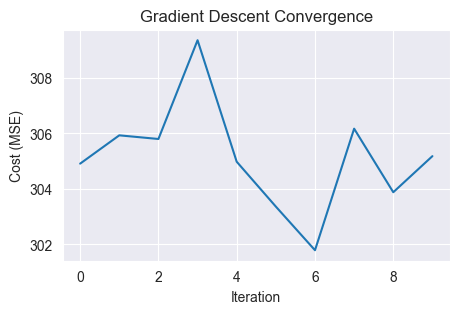

last: 305.1815015659465


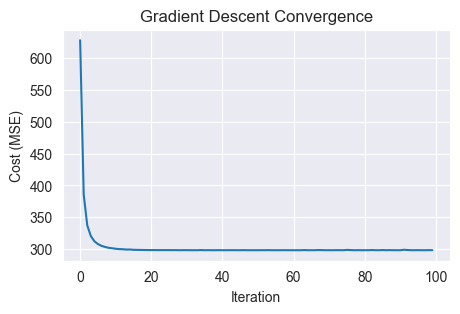

last: 298.21002933792374


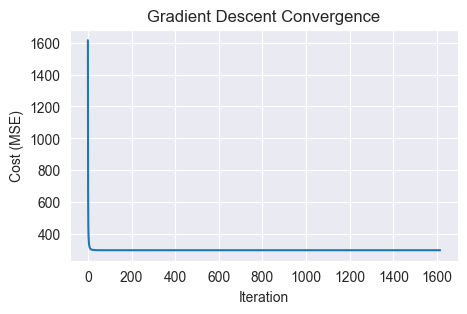

last: 298.12718296388397


In [16]:
# results_regressors = []

def test_gradient_descent(iterations):
    if f'Gradient Descent - {iterations} iterations' not in models_info:
        gd_regressor = Pipeline([
            ('preprocessor', regression_preprocessor),
            ('regressor', GradientDescentLinearRegression(
                learning_rate='adaptive',
                iterations = iterations
            ))
        ])

        param_grid = {
            "regressor__learning_rate": [0.001, 0.01, 0.1, 'adaptive'],
            "regressor__batch_size": [None, 16, 32, 64]
        }

        grid_search = GridSearchCV(
            gd_regressor,
            param_grid,
            scoring='neg_mean_squared_error',
            cv=presplit,
            n_jobs= - 1,
            refit=True,
            error_score=np.nan,
            verbose=0,
        )
        grid_search.fit(new_X_dummy, new_y_dummy)
        models_info.update({
            f'Gradient Descent - {iterations} iterations' : {
                'base_model' : gd_regressor,
                'basic_model' : grid_search.best_estimator_,
                'param_grid' : param_grid,
                'classifier' : False
            }


        })
    model = models_info[f'Gradient Descent - {iterations} iterations']['basic_model']

    model.fit(new_X_train, new_y_train)
    coefs = list(model.named_steps['regressor'].coef_)
    coefs.append(model.named_steps['regressor'].intercept_)
    names = list(map(lambda x: x.split('__')[1], model.named_steps['preprocessor'].get_feature_names_out()))
    names.append('Intercept')
    result_row = {
        'Name' : f'Gradient Descent - {iterations} iterations',
        'Parameters': model.named_steps['regressor'].get_params(),
        'Coefficients' : list(zip(names, coefs))
    }
    y_pred = model.predict(new_X_train)
    result_row.update({'Training' : mean_squared_error(new_y_train, y_pred)})
    y_pred = model.predict(new_X_val)
    result_row.update({'Validation' : mean_squared_error(new_y_val, y_pred)})
    y_pred = model.predict(new_X_test)
    result_row.update({'Testing' : mean_squared_error(new_y_test, y_pred)})
    results_regressors.append(result_row)
    history = model.named_steps['regressor'].cost_history_
    plt.figure(figsize=(5, 3))
    plt.plot(history)
    plt.xlabel('Iteration')
    plt.ylabel('Cost (MSE)')
    plt.title('Gradient Descent Convergence')
    plt.show()
    plt.close()
    print('last:',history[len(history) - 1])


test_gradient_descent(10)
test_gradient_descent(100)
test_gradient_descent(10000)

As we can see from the above results, running the algorithm for more than 100 epochs barely affects the accuracy of the model

## Gradient Descent with PyTorch

This PyTorch - based linear regression model uses automatic differentiation and GPU acceleration to optimize the model parameters. It defines a simple neural network with a single linear layer representing the regression weights and bias. The training process iterates over multiple epochs, using mini - batches of data loaded via a DataLoader. For each batch, the model performs a forward pass to compute predictions, calculates the mean squared error loss, then backpropagates the gradients to update the weights using stochastic gradient descent (SGD). Validation loss can be monitored during training to track performance. PyTorch’s efficient tensor operations and gradient management allow flexible and scalable model training compared to manual implementations.


In [17]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)


class TorchLinearRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=1000, batch_size=64, learning_rate=0.01, device=torch.device('cpu'), random_state = 42):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.device = device
        self.model_ = None
        self.random_state = random_state

        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)
            if device.type == 'cuda':
                torch.cuda.manual_seed_all(self.random_state)
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = False

    def fit(self, X, y, validation_data=None):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32).view( - 1, 1)

        input_dim = X.shape[1]
        self.model_ = LinearRegressionModel(input_dim).to(self.device)

        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True, pin_memory=True)

        if validation_data is not None:
            X_val, y_val = validation_data
            X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(self.device)
            y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view( - 1, 1).to(self.device)

        criterion = nn.MSELoss()
        optimizer = optim.SGD(self.model_.parameters(), lr=self.learning_rate)
        for epoch in range(self.epochs):
            self.model_.train()
            for batch_x, batch_y in dataloader:
                batch_x = batch_x.to(self.device, non_blocking=True)
                batch_y = batch_y.to(self.device, non_blocking=True)

                optimizer.zero_grad()
                outputs = self.model_(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if validation_data is not None:
                self.model_.eval()
                with torch.no_grad():
                    val_outputs = self.model_(X_val_tensor)
                    val_loss = criterion(val_outputs, y_val_tensor)
                print(f"Epoch {epoch+1}/{self.epochs} - Validation Loss: {val_loss.item():.6f}")

        if self.device.type == 'cuda':
            torch.cuda.synchronize()
        return self

    def predict(self, X):
        self.model_.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            predictions = self.model_(X_tensor).cpu().numpy()
        return predictions

    @property
    def coef_(self):
        return list(map(lambda x : float(x), self.model_.linear.weight.detach().cpu().numpy().flatten()))

    @property
    def intercept_(self):
        return float(self.model_.linear.bias.item())




In [18]:
if 'time_cuda' not in globals():
    start = time.time()
    pytorch_regressor_cuda = Pipeline([
        ('preprocessor', regression_preprocessor),
        ('regressor', TorchLinearRegressor(device=torch.device('cuda')))
    ])
    pytorch_regressor_cuda.fit(new_X_train, new_y_train)
    time_cuda = f"Training completed in {time.time() - start:.4f} seconds"

if 'time_cpu' not in globals():
    pytorch_regressor_cpu = Pipeline([
        ('preprocessor', regression_preprocessor),
        ('regressor', TorchLinearRegressor(device=torch.device('cpu')))
    ])
    start = time.time()
    pytorch_regressor_cpu.fit(new_X_train, new_y_train)
    time_cpu = f"Training completed in {time.time() - start:.4f} seconds"



print(f"\nPytorch Implementation (CUDA)\n{time_cuda}")


print(f"\nPytorch Implementation (CPU)\n{time_cpu}")



def test_pytorch(iterations):
    if f'Pytorch - {iterations} epochs' not in models_info:
        pytorch_regressor_cpu = Pipeline([
            ('preprocessor', regression_preprocessor),
            ('regressor', TorchLinearRegressor(epochs=iterations, device=torch.device('cpu')))
        ])

        param_grid = {
            "regressor__learning_rate": [0.001, 0.01],
            "regressor__batch_size": [None, 16, 32]
        }


        grid_search = GridSearchCV(
            pytorch_regressor_cpu,
            param_grid,
            scoring='neg_mean_squared_error',
            cv=presplit,
            n_jobs=1,
            refit=True,
            error_score=np.nan,
            verbose=0
        )

        grid_search.fit(new_X_dummy, new_y_dummy)
        models_info.update({
            f'Pytorch - {iterations} epochs' : {
                'base_model' : pytorch_regressor_cpu,
                'basic_model' : grid_search.best_estimator_,
                'param_grid' : param_grid,
                'classifier' : False
            }
        })
    model = models_info[f'Pytorch - {iterations} epochs']['basic_model']
    model.fit(new_X_train, new_y_train)
    coefs = list(model.named_steps['regressor'].coef_)
    coefs.append(model.named_steps['regressor'].intercept_)
    names = list(map(lambda x: x.split('__')[1], model.named_steps['preprocessor'].get_feature_names_out()))
    names.append('Intercept')
    result_row = {
        'Name' : f'Pytorch - {iterations} epochs',
        'Parameters': model.named_steps['regressor'].get_params(),
        'Coefficients' : list(zip(names, coefs))
    }
    y_pred = model.predict(new_X_train)
    result_row.update({'Training' : mean_squared_error(new_y_train, y_pred)})
    y_pred = model.predict(new_X_val)
    result_row.update({'Validation' : mean_squared_error(new_y_val, y_pred)})
    y_pred = model.predict(new_X_test)
    result_row.update({'Testing' : mean_squared_error(new_y_test, y_pred)})
    results_regressors.append(result_row)


test_pytorch(10)
test_pytorch(100)


Pytorch Implementation (CUDA)
Training completed in 41.2235 seconds

Pytorch Implementation (CPU)
Training completed in 11.3328 seconds


While normally one would expect training on the GPU to be substantially faster, the relatively small size of our dataset (around 2000 rows) means the cost of moving the data to the GPU isn't outweighed by the benefit of more optimized parallel computation

## Results table
Below are tables that sum up the different used classifiers and regressors, and their scores

In [19]:
# df_results_classifiers = pd.DataFrame(results_classifiers)
# display(df_results_classifiers.drop('Parameters', axis=1))
# for dictionary in results_classifiers:
#     print(dictionary['Name'])
#     display(pd.DataFrame(dictionary['Parameters'].items(), columns = ['Name', 'Values']))
#
# df_results_regressors = pd.DataFrame(results_regressors)
# display(df_results_regressors.drop(['Parameters', 'Coefficients'], axis=1))
# for dictionary in results_regressors:
#     has_params = 'Parameters' in dictionary and dictionary['Parameters']
#     has_coefs = 'Coefficients' in dictionary and dictionary['Coefficients']
#     if has_params or has_coefs:
#         print(dictionary['Name'])
#     if has_params:
#         display(pd.DataFrame(dictionary['Parameters'].items(), columns = ['Name', 'Values']))
#     if has_coefs:
#         display(pd.DataFrame(dictionary['Coefficients'], columns = ['Name', 'Values']))
#
#
# names = ['Coefficient name']
# values = list(map(lambda x: [x[0]], results_regressors[0]['Coefficients']))
# for dictionary in results_regressors:
#     if 'Coefficients' in dictionary and dictionary['Coefficients']:
#         names.append(dictionary['Name'])
#         coefs = list(map(lambda x: x if isinstance(x,str) else x[1], dictionary['Coefficients']))
#         for i in range(len(coefs)):
#             values[i].append(coefs[i])
#
# display(pd.DataFrame(values, columns = names))


,Name,Training,Validation,Testing
0,Random Forest Classifier,1.000000,0.950237,0.940898
1,Decision Tree,0.999210,0.938389,0.914894
2,SVC Linear,0.988942,0.964455,0.973995
3,Logistic Regression,0.977093,0.957346,0.969267


Random Forest Classifier


,Name,Values
0,bootstrap,False
1,ccp_alpha,0.0
2,class_weight,None
3,criterion,gini
4,max_depth,None
5,max_features,sqrt
6,max_leaf_nodes,None
7,max_samples,None
8,min_impurity_decrease,0.0
9,min_samples_leaf,1


Decision Tree


,Name,Values
0,ccp_alpha,0.0
1,class_weight,None
2,criterion,gini
3,max_depth,10
4,max_features,None
5,max_leaf_nodes,None
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,2
9,min_weight_fraction_leaf,0.0


...

,Name,Values
0,Age,5.937535
1,Height,11.113529
2,Vegetables,5.197086
3,Meals,0.692516
4,Water,0.612663
5,Activity,-2.255823
6,Devices,-0.470807
7,Family History,8.033650
8,High caloric,1.294717
9,Smoking,-0.278097


Pytorch - 100 epochs


,Name,Values
0,batch_size,16
1,device,cpu
2,epochs,100
3,learning_rate,0.001
4,random_state,42


,Name,Values
0,Age,5.992359
1,Height,11.545100
2,Vegetables,5.223820
3,Meals,0.585156
4,Water,0.583146
5,Activity,-2.471827
6,Devices,-0.558810
7,Family History,8.089715
8,High caloric,1.375350
9,Smoking,-0.405757


,Coefficient name,Closed form,Gradient Descent - 10 iterations,Gradient Descent - 100 iterations,Gradient Descent - 10000 iterations,Pytorch - 10 epochs,Pytorch - 100 epochs
0,Age,6.058,6.481891,6.072437,6.048317,5.937535,5.992359
1,Height,11.534,11.744126,11.509911,11.545391,11.113529,11.545100
2,Vegetables,5.214,5.742886,5.193628,5.206110,5.197086,5.223820
3,Meals,0.625,0.744440,0.608514,0.622820,0.692516,0.585156
4,Water,0.608,0.333845,0.574548,0.611997,0.612663,0.583146
5,Activity,-2.450,-1.979737,-2.468717,-2.448918,-2.255823,-2.471827
6,Devices,-0.509,0.306207,-0.512701,-0.517820,-0.470807,-0.558810
7,Family History,8.087,7.681506,8.085347,8.087016,8.033650,8.089715
8,High caloric,1.366,0.775447,1.370310,1.369066,1.294717,1.375350
9,Smoking,-0.469,-0.307625,-0.453131,-0.476438,-0.278097,-0.405757


The classification models show very high accuracy across training, validation, and test sets, with the Random Forest Classifier achieving perfect accuracy on training data (1.0) but slightly lower on validation and test, indicating some minor overfitting. The other classifiers, such as SVC Linear and Logistic Regression, have strong and consistent performance, suggesting good generalization.

For regression models, the numbers represent error metrics (likely Mean Squared Error or similar), where lower values indicate better fit. The closed - form solution consistently yields the lowest error across all datasets, indicating it’s the most accurate and stable method here.

Gradient Descent improves with more iterations, with 10,000 iterations closely matching the closed - form results, showing that sufficiently long training converges well.

The PyTorch implementations with 10 and 100 epochs perform reasonably well but do not quite reach the accuracy of the closed - form or fully converged gradient descent, suggesting either the need for more epochs, tuning, or differences in optimization details.

# Model Optimization

### Logistic regression model

This SoftmaxRegression class implements a multi - class logistic regression model trained via gradient descent using the softmax function to compute class probabilities. It optimizes the cross - entropy loss with optional L1 or L2 regularization to prevent overfitting. The model supports early stopping based on a tolerance threshold for loss improvement and tracks weight updates during training. It provides methods for predicting class probabilities and labels, and includes a utility to visualize training and test loss over iterations, aiding in understanding model convergence and performance stability.

In [20]:
from sklearn.metrics import log_loss
from sklearn.utils.validation import check_is_fitted, check_array
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelBinarizer
from sklearn.utils import check_X_y


class SoftmaxRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.001, max_iter=100, tol=1e-4, regularization = None, lambda_ = 0.001, random_state=42):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.weight_history = None
        self.regularization = regularization
        self.lambda_ = lambda_

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _cross_entropy(self, X, y, weights):
        m = X.shape[0]
        z = np.dot(X, weights.T)
        prob = self.softmax(z)
        log_likelihood = -np.log(prob[range(m), y])
        loss = np.sum(log_likelihood) / m
        return loss

    def fit(self, X, y):
        self.weight_history = []
        X, y = check_X_y(X, y)
        if not np.issubdtype(y.dtype, np.integer):
            from sklearn.preprocessing import LabelEncoder
            self.label_encoder_ = LabelEncoder()
            y = self.label_encoder_.fit_transform(y)
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)

        self.label_binarizer_ = LabelBinarizer()
        y_onehot = self.label_binarizer_.fit_transform(y)

        np.random.seed(self.random_state)
        n_features = X.shape[1]
        self.weights_ = np.random.randn(self.n_classes_, n_features) * 0.01
        self.weight_history.append(self.weights_.copy())

        prev_loss = float('inf')
        for i in range(self.max_iter):
            z = np.dot(X, self.weights_.T)
            prob = self.softmax(z)

            gradient = np.dot((prob - y_onehot).T, X)

            if self.regularization in ['l2', 'both']:
                gradient += 2 * self.lambda_ * self.weights_
            if self.regularization in ['l1', 'both']:
                gradient += self.lambda_ * np.sign(self.weights_)

            self.weights_ -= self.learning_rate * gradient
            self.weight_history.append(self.weights_.copy())

            loss = self._cross_entropy(X, y, self.weights_)
            if np.abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

        return self

    def predict_proba(self, X, weights=None):
        if weights is None:
            weights = self.weights_
        check_is_fitted(self)
        X = check_array(X)
        z = np.dot(X, weights.T)
        return self.softmax(z)

    def predict(self, X, weights=None):
        if weights is None:
            weights = self.weights_
        proba = self.predict_proba(X, weights)
        y_pred = np.argmax(proba, axis=1)
        if hasattr(self, 'label_encoder_'):
            return self.label_encoder_.inverse_transform(y_pred)
        return y_pred

    def draw_cost_history(self, X_train, y_train, X_test, y_test, preprocessor=None):

        check_is_fitted(self)

        # Ensure data is transformed using full pipeline
        if preprocessor is not None:
            if isinstance(preprocessor, Pipeline):
                X_train = preprocessor.transform(X_train)
                X_test = preprocessor.transform(X_test)
            else:
                raise ValueError("`preprocessor` must be a Pipeline including all steps used during training.")

        # Ensure labels are encoded like in training
        if hasattr(self, 'label_encoder_'):
            y_train_enc = self.label_encoder_.transform(y_train)
            y_test_enc = self.label_encoder_.transform(y_test)
        else:
            y_train_enc = y_train
            y_test_enc = y_test

        train_losses = []
        test_losses = []

        for weights in self.weight_history:
            y_train_proba = self.predict_proba(X_train, weights=weights)
            y_test_proba = self.predict_proba(X_test, weights=weights)

            train_loss = log_loss(y_train_enc, y_train_proba, labels=self.classes_)
            test_loss = log_loss(y_test_enc, y_test_proba, labels=self.classes_)

            train_losses.append(train_loss)
            test_losses.append(test_loss)

        plt.figure(figsize=(6, 4))
        plt.plot(train_losses, label='Train Cross - Entropy Loss')
        plt.plot(test_losses, label='Test Cross - Entropy Loss')
        plt.xlabel('Iteration')
        plt.ylabel('Cross - Entropy Loss')
        plt.title('Cost History During Training')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()

    def get_weights(self):
        weights = self.weight_history[ - 1]  # shape (n_classes, n_features)
        weights = np.abs(weights)           # take absolute value element - wise
        mean_per_feature = np.mean(weights, axis=0)  # mean across classes, for each feature
        return [round(float(x), 6) for x in mean_per_feature]




In [21]:
from sklearn.metrics import classification_report
import copy

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',SoftmaxRegression())
])

import copy

def with_added_steps(self, *steps):
    model = copy.deepcopy(self)
    tuplename = 0
    existing_names = {name for name, _ in model.steps}

    for step in steps:
        if not isinstance(step, tuple):
            base_name = f"step_"
            tuplename += 1
            name = f'{base_name}{tuplename}'
            count = 1
            while name in existing_names:
                name = f"{base_name}_{count}"
                count += 1
            step = (name, step)
        else:
            name, transformer = step
            base_name = name
            count = 1
            while name in existing_names:
                name = f"{base_name}_{count}"
                count += 1
            step = (name, transformer)

        model.steps.insert( - 1, step)
        existing_names.add(step[0])

    return model

Pipeline.with_added_steps = with_added_steps

def with_params(self, *params):
    model = copy.deepcopy(self)

    # Get last step name and estimator
    last_step_name, last_estimator = model.steps[ - 1]

    # Prepare the full param dict for the last step
    prefixed_params = {f"{last_step_name}__{key}": value for key, value in params}

    # Update parameters on the copy
    model.set_params(**prefixed_params)

    return model



lr_model.fit(X_train, y_train)

poly_lr_model = with_added_steps(lr_model, ('poly',PolynomialFeatures(degree=2, include_bias=True)))
poly_lr_model.fit(X_train, y_train)

Pipeline.with_params = with_params

## Cross validation

Cross - validation is a robust technique used to evaluate the generalization performance of a machine learning model. It involves splitting the dataset into multiple subsets or "folds." In each iteration, one fold is held out as the validation set while the model is trained on the remaining folds. This process is repeated such that each fold serves as the validation set once. The results are then averaged to produce a more reliable estimate of model performance. A common variant is *k* - fold cross - validation, where the data is divided into $k$ equally sized folds. The average validation error is computed as the mean of errors for each fold. Cross - validation helps prevent overfitting by ensuring the model’s evaluation is not dependent on a single train - test split, providing insight into how the model might perform on unseen data.


<Figure size 500x300 with 0 Axes>

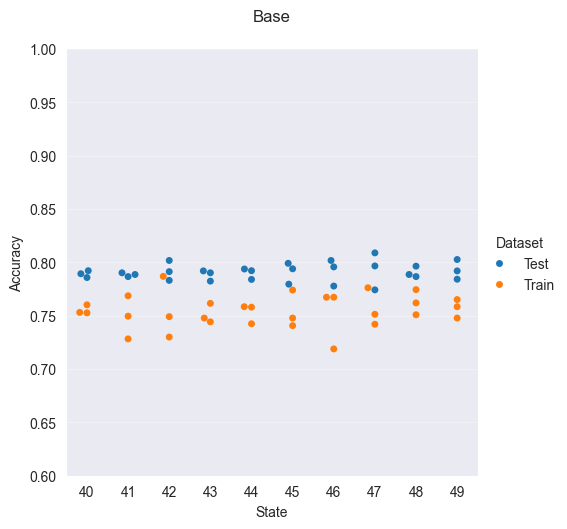

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import seaborn as sns


cross_val_results = {}

def cross_vals(name, model, show = True):
    if name not in cross_val_results:
        cross_val_res = []
        for state in range(40,50):
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=state)
            cross_val = cross_validate(model, X_dummy, y_dummy, cv=cv, scoring = 'accuracy', return_train_score=True)
            scores = cross_val['test_score']
            train_scores = cross_val['train_score']
            cross_val_res.append(
                {
                    'State': state,
                    'Accuracy 1' : scores[0], 'Training 1' : train_scores[0],
                    'Accuracy 2' : scores[1], 'Training 2' : train_scores[1],
                    'Accuracy 3' : scores[2], 'Training 3' : train_scores[2],
                    'Mean Accuracy': scores.mean()
                }
            )
        cross_val_results.update({name : cross_val_res})


    data_frame = pd.DataFrame(cross_val_results[name])

    if show:
        train_melt = data_frame.melt(id_vars=['State'],
                          value_vars=['Accuracy 1', 'Accuracy 2', 'Accuracy 3'],
                          var_name='fold',
                          value_name='Accuracy')
        train_melt['Dataset'] = 'Train'
        test_melt = data_frame.melt(id_vars=['State', 'Mean Accuracy'],
                            value_vars=['Training 1', 'Training 2', 'Training 3'],
                            var_name='Fold',
                            value_name='Accuracy')
        test_melt['Dataset'] = 'Test'

        combined = pd.concat([test_melt, train_melt], ignore_index=True)
        plt.figure(figsize=(5, 3))
        sns.catplot(data=combined, x='State', y='Accuracy', width=0.5, kind='swarm', hue='Dataset')
        plt.title(f'{name}', pad=20)
        plt.xlabel('State')
        plt.ylim(0.6, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        plt.close()

cross_vals('Base', lr_model)


The results for both the test and train data are quite low so far, which suggests slight underfitting

## Polynomial features

The model we have is quite simple - it only has around 20 features. This can lead to problems with model accuracy, as there is not much data to base the predictions on. That is especially true for regressions which normally can only find linear relations - often not enough to find the proper repationships. To remedy this problem, we can increase the model complexity.

One common way to increase the complexity of a linear model is by adding polynomial features. Instead of using the original features $x_1, x_2, \ldots, x_n$, we create new features by including powers and interactions of the original features, such as $x_1^2$, $x_1 x_2$, $x_2^3$, and so on. This allows the model to capture nonlinear relationships in the data while still fitting a linear model to the transformed features. Formally, if the original feature vector is $\mathbf{x} = [x_1, x_2, \ldots, x_n]$, the polynomial feature transformation of degree $d$ maps $\mathbf{x}$ to:

$$
\phi(\mathbf{x}) = \left[ x_1, x_2, \ldots, x_n, x_1^2, x_1 x_2, \ldots, x_n^d \right]
$$

Increasing the degree $d$ raises model flexibility but also risks overfitting, making regularization techniques or careful cross - validation essential to control model complexity.


<Figure size 500x300 with 0 Axes>

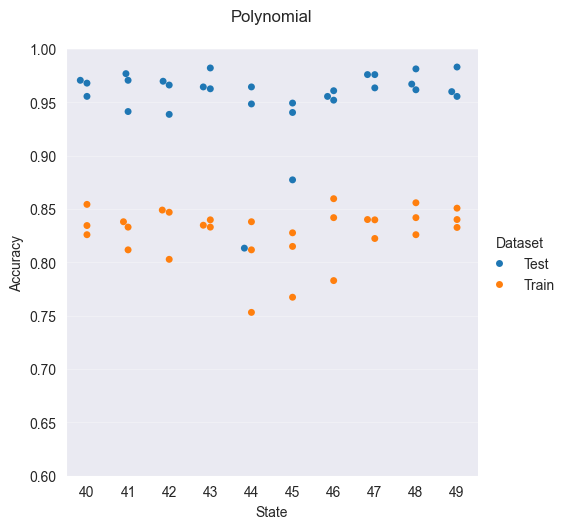

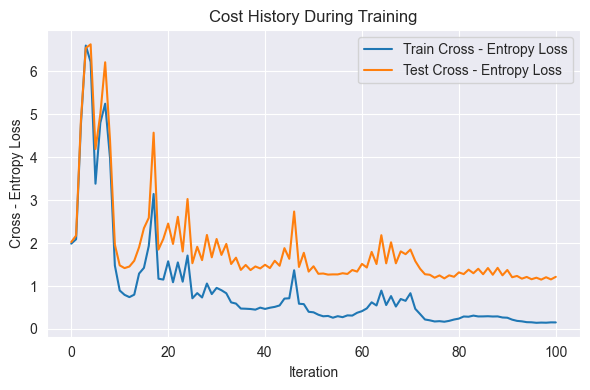

In [23]:
cross_vals('Polynomial', poly_lr_model)
poly_lr_model.named_steps['classifier'].draw_cost_history(X_train, y_train, X_test, y_test, poly_lr_model[: - 1])

As we can see, as expected, the overfit of the model increased - we are seeing much bigger differences between the best and worst folds, however, the average score has increased. To remedy the overfit, we can utilize the next form of optimization - regularization.

## L1 and L2 Regularization

L1 and L2 regularization are techniques used to prevent overfitting by adding a penalty term to the loss function that the model tries to minimize. L2 regularization, also known as Ridge regression, adds a penalty proportional to the sum of the squared weights:

$$
\text{Loss}_{L2} = \text{Loss} + \lambda \sum_{j} w_j^2
$$

This encourages smaller weights overall and tends to distribute the penalty evenly, shrinking weights smoothly. L1 regularization, or Lasso, adds a penalty proportional to the sum of the absolute values of the weights:

$$
\text{Loss}_{L1} = \text{Loss} + \lambda \sum_{j} |w_j|
$$

This often drives some weights exactly to zero, promoting sparsity and feature selection. Combining both (Elastic Net) can balance these effects, improving generalization and interpretability.


<Figure size 500x300 with 0 Axes>

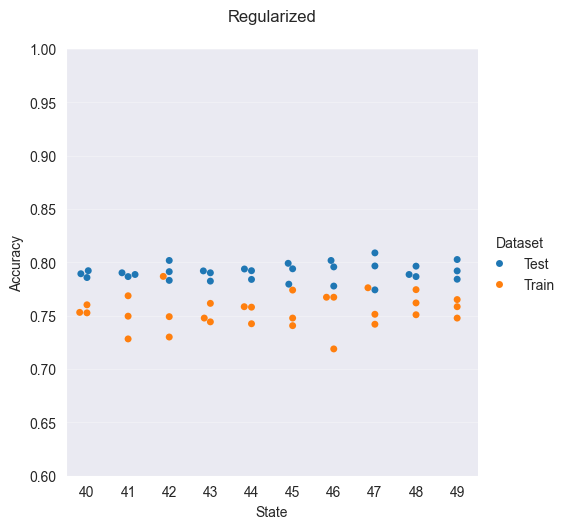

In [24]:
lr_model_regularized = lr_model.with_params(('regularization', 'both'))
cross_vals('Regularized', lr_model_regularized)

To properly visualize the effect of regularization, we will perform it for the model with polynomial features - it struggles with overfitting so the results will be most visible

<Figure size 500x300 with 0 Axes>

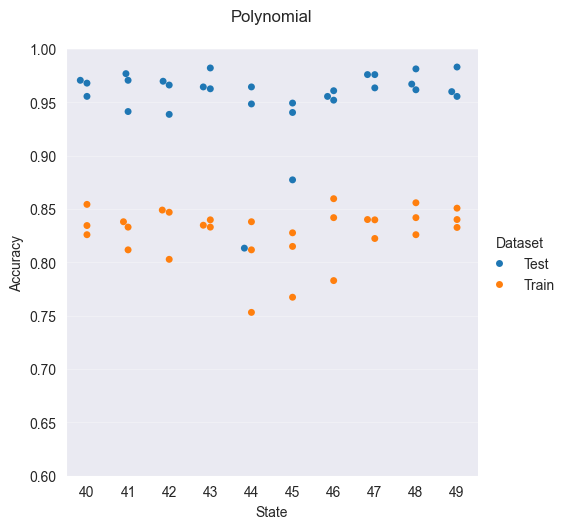

<Figure size 500x300 with 0 Axes>

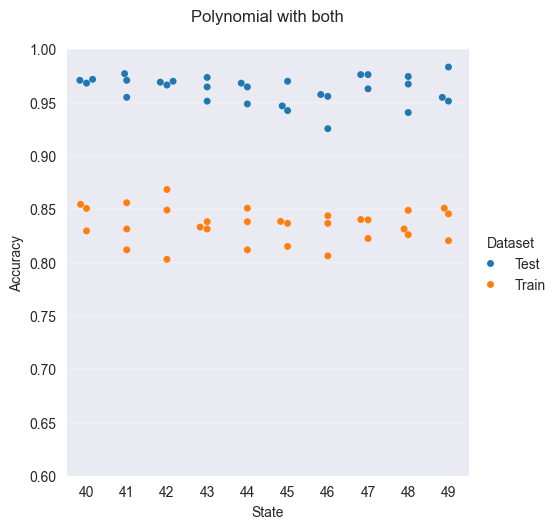

In [25]:
cross_val_results = {}
cross_vals('Polynomial', poly_lr_model)
poly_lr_model_regularized = poly_lr_model.with_params(('regularization', 'both'), ('lambda_', 0.001))

cross_vals('Polynomial with both', poly_lr_model_regularized)

As we can see, the results for each fold after regularization are more uniform, which suggests the reduction of overfitting

In [26]:
lr_model_l1 = lr_model.with_params(('regularization', 'l1'), ('lambda_', 100))
lr_model_l2 = lr_model.with_params(('regularization', 'l2'), ('lambda_', 100))
lr_model_regularized = lr_model.with_params(('regularization', 'both'), ('lambda_', 100))
lr_model.fit(X_train, y_train)
lr_model_l1.fit(X_train, y_train)
lr_model_l2.fit(X_train, y_train)
lr_model_regularized.fit(X_train, y_train)

def pipeline_get_weights(self):
    return self[ - 1].get_weights()
Pipeline.get_weights = pipeline_get_weights

feature_names = lr_model[: - 1].get_feature_names_out()

weights_data = {
    'Base': lr_model.get_weights(),
    'L1': lr_model_l1.get_weights(),
    'L2': lr_model_l2.get_weights(),
    'Both': lr_model_regularized.get_weights(),
}

# Create DataFrame with feature names as index
df_weights = pd.DataFrame(weights_data, index=feature_names)
df_weights.index.name = 'Feature'

# Display the DataFrame
pd.set_option('display.max_rows', None)  # Optional: show all rows
display(df_weights)

,Base,L1,L2,Both
Feature,,,,
numeric__Age,0.420051,0.060527,0.135738,0.089111
numeric__Height,0.499834,0.070574,0.067157,0.039218
numeric__Weight,2.318178,0.372682,0.331568,0.175207
numeric__Vegetables,0.420672,0.094925,0.130025,0.078766
numeric__Meals,0.216725,0.053680,0.093690,0.079985
numeric__Water,0.198394,0.079443,0.076814,0.058499
numeric__Activity,0.208897,0.067380,0.070859,0.068754
numeric__Devices,0.138293,0.045317,0.045555,0.067137
boolean__Family History,0.405568,0.051280,0.156779,0.086468


The results demonstrate the impact of regularization on the learned feature weights in a softmax regression model. Without any regularization (the base case), the model assigns relatively large weights to features, which can lead to overfitting, especially in the presence of noise or collinearity. When L1 regularization is applied, many weights are significantly reduced, with several approaching zero - this is expected, as L1 promotes sparsity by encouraging the model to ignore less important features altogether. L2 regularization, on the other hand, produces a more gradual shrinkage across all weights, retaining more features but reducing their individual influence to prevent over - reliance. The combination of L1 and L2 (Elastic Net) yields the most aggressive reduction, balancing the benefits of both sparsity and smooth penalization. Overall, these results confirm that regularization effectively simplifies the model, potentially improving its generalization by limiting overfitting and reducing model complexity.

## Sample balancing
Class imbalance is a common issue in classification tasks, where some classes have significantly more samples than others. This imbalance can cause models to become biased toward the majority classes, leading to poor performance on the underrepresented ones. To address this, we explored two common resampling techniques: SMOTE (Synthetic Minority Oversampling Technique) and Random Undersampling. SMOTE works by generating synthetic samples for the minority classes, effectively increasing their representation without duplicating data. In contrast, Random Undersampling reduces the number of samples in the majority classes by randomly removing instances, aiming to balance the dataset through reduction. Both methods were applied in conjunction with a custom logistic regression model to observe their impact on performance in a multiclass classification setting.

In [27]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.under_sampling import RandomUnderSampler

smote = imbPipeline([('preprocessor', preprocessor), ('smote',SMOTE(random_state=42))])
under = imbPipeline([('preprocessor', preprocessor), ('under',RandomUnderSampler(random_state=42))])
_, y_train_smote = smote.fit_resample(X_train, y_train)
_, y_train_under = under.fit_resample(X_train, y_train)

print("Original class distribution:", y_train.value_counts())
print("Smote class distribution:", y_train_smote.value_counts())
print("Undersampler class distribution:", y_train_under.value_counts())

lr_model_smote = imbPipeline([
    ('preprocessor', preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('classifier',SoftmaxRegression())
])

lr_model_under = imbPipeline([
    ('preprocessor', preprocessor),
    ('under',RandomUnderSampler(random_state=42)),
    ('classifier',SoftmaxRegression())
])

y_pred = lr_model.predict(X_test)
print("Before SMOTE")
print(classification_report(y_test, y_pred))

lr_model_smote.fit(X_train, y_train)
y_pred = lr_model_smote.predict(X_test)
print("\nAfter SMOTE:")
print(classification_report(y_test, y_pred))

lr_model_under.fit(X_train, y_train)
y_pred = lr_model_under.predict(X_test)
print("\nAfter Undersampling:")
print(classification_report(y_test, y_pred))

Original class distribution: NObeyesdad         
Obesity_Type_I         214
Obesity_Type_III       186
Overweight_Level_II    179
Obesity_Type_II        178
Overweight_Level_I     178
Insufficient_Weight    166
Normal_Weight          165
Name: count, dtype: int64
Smote class distribution: NObeyesdad         
Insufficient_Weight    214
Normal_Weight          214
Obesity_Type_I         214
Obesity_Type_II        214
Obesity_Type_III       214
Overweight_Level_I     214
Overweight_Level_II    214
Name: count, dtype: int64
Undersampler class distribution: NObeyesdad         
Insufficient_Weight    165
Normal_Weight          165
Obesity_Type_I         165
Obesity_Type_II        165
Obesity_Type_III       165
Overweight_Level_I     165
Overweight_Level_II    165
Name: count, dtype: int64
Before SMOTE
                     precision    recall  f1-score   support

Insufficient_Weight       0.75      0.98      0.85        56
      Normal_Weight       0.74      0.40      0.52        62
     Obesi

Before applying any resampling, the model achieved a respectable overall accuracy of 76%, but performance varied notably across classes  -  for example, Normal_Weight had a low recall of 0.40, indicating poor sensitivity to this class.

After applying SMOTE (Synthetic Minority Oversampling Technique), we observed a slight improvement in overall accuracy to 77%, along with modest gains in the macro and weighted average scores. Notably, minority classes like Overweight_Level_II saw improved precision and recall, suggesting that SMOTE helped the model better capture underrepresented patterns without degrading performance on well-represented classes.

When using Random Undersampling, the model's performance was similar to the original, with a slightly reduced overall accuracy of 75%. However, it preserved high recall on classes like Insufficient_Weight and Obesity_Type_III. Undersampling generally risks discarding potentially useful data, which can lead to slightly less stable performance, but it remains a viable approach when computational efficiency or reduced training time is prioritized.

In summary, SMOTE provided the best balance across metrics without sacrificing accuracy, making it the most effective resampling technique for this dataset.

## Hyperparameter adjustment

When building machine learning models, choosing the right hyperparameters can significantly impact performance. Rather than manually tuning these values, GridSearch offers a systematic approach by exhaustively searching over a predefined set of hyperparameter combinations. Using cross-validation, GridSearch evaluates each combination on multiple training/validation splits to ensure that the selected parameters generalize well to unseen data. This approach helps identify the optimal configuration for a given model, improving both accuracy and robustness. In this section, we apply GridSearchCV from scikit-learn to find the best hyperparameters for our custom logistic regression model.

In [28]:
# Softmax Regression GridSearch with Caching
if 'softmax_grid_result' not in globals():
    param_grid = {
        'classifier__learning_rate': [0.01, 0.001],
        'classifier__max_iter': [100, 300, 1000],
        'classifier__regularization': [None, 'l1', 'l2', 'both'],
        'classifier__lambda_': [100, 10, 1, 0.1]
    }

    # GridSearchCV with cross-validation
    grid_search = GridSearchCV(lr_model_regularized, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    softmax_grid_result = grid_search  # Cache result

grid_search = softmax_grid_result
print("Softmax Regression")


params1 = lr_model_regularized[-1].get_params()
params2 = grid_search.best_estimator_[-1].get_params()

for ((name, value1), (_, value2)) in zip(params1.items(), params2.items()):
    if value1 != value2:
        print(name, ": Base - ", value1, ', New - ', value2)

# Evaluation
y_pred_base = lr_model_regularized.predict(X_test)
y_pred = grid_search.predict(X_test)

print('\nBase logistic regression report')
print(classification_report(y_test, y_pred_base))

print("\nOptimized logistic regression report:")
print(classification_report(y_test, y_pred))

estimator = models_info['Random Forest Classifier']['base_model']
corrected_model = models_info['Random Forest Classifier']['basic_model']

params1 = estimator[-1].get_params()
params2 = corrected_model[-1].get_params()

for ((name, value1), (_, value2)) in zip(params1.items(), params2.items()):
    if value1 != value2:
        print(name, ": Base - ", value1, ', New - ', value2)

# Evaluation
estimator.fit(X_train, y_train)
y_pred_base = estimator.predict(X_test)
y_pred = corrected_model.predict(X_test)

print('\nBase decision tree report')
print(classification_report(y_test, y_pred_base))

print("\nOptimized decision tree report:")
print(classification_report(y_test, y_pred))


Softmax Regression
lambda_ : Base -  100 , New -  1
max_iter : Base -  100 , New -  1000
regularization : Base -  both , New -  l1

Base logistic regression report
                     precision    recall  f1-score   support

Insufficient_Weight       0.00      0.00      0.00        56
      Normal_Weight       0.67      0.10      0.17        62
     Obesity_Type_I       1.00      0.01      0.03        78
    Obesity_Type_II       0.51      0.76      0.61        58
   Obesity_Type_III       0.97      1.00      0.98        63
 Overweight_Level_I       0.22      0.50      0.30        56
Overweight_Level_II       0.22      0.58      0.32        50

           accuracy                           0.40       423
          macro avg       0.51      0.42      0.34       423
       weighted avg       0.55      0.40      0.34       423


Optimized logistic regression report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.82      1.00      0.90        56


The results of the grid search optimization clearly demonstrate the significant impact of hyperparameter tuning - especially when the baseline model is suboptimal. For Softmax Regression, the base model was deliberately configured with poor hyperparameters, resulting in a very low accuracy of 40% and particularly poor performance on classes such as Insufficient Weight and Obesity Type I. After applying GridSearchCV, the optimized model achieved a dramatic performance increase, reaching 87% accuracy and strong improvements across all classes. This stark contrast highlights the importance of tuning parameters like learning_rate, max_iter, regularization, and lambda_ in custom implementations.

In contrast, the Decision Tree classifier began with a well-chosen baseline configuration, already achieving a high accuracy of 94%. After grid search tuning, performance remained virtually unchanged, with only marginal gains in some class-level metrics. This emphasizes a key insight: grid search yields the most value when the initial model is far from optimal. When hyperparameters are already well selected - either through intuition, prior tuning, or default values - further optimization may yield diminishing returns.

These results collectively show that while grid search can drastically improve underperforming models, its effectiveness depends heavily on the quality of the initial configuration.

## Ensemble
Ensemble learning combines predictions from multiple models to improve generalization and robustness. In this section, we explore:

- Voting Classifier: Aggregates predictions from multiple base classifiers using majority vote (hard voting) or averaged class probabilities (soft voting). Ideal when individual models make different types of errors.

- Stacking Classifier: Trains a meta-model on the predictions of base models to learn how to best combine them.

- Mixture of Experts (MoE): A more flexible ensemble where specialized models (experts) are trained on different regions of the input space, and a gating mechanism decides which experts to trust. This method is especially useful in large-scale or heterogeneous data problems, where a single model struggles to generalize well across the entire input space.

These ensemble techniques aim to reduce variance, bias, or both, and are particularly effective when individual models perform well on different subsets of the data - as observed in earlier experiments.

In [29]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import StackingClassifier

logreg = LogisticRegression(C=0.1, max_iter=10)
tree = DecisionTreeClassifier(max_depth=2)        # shallow tree to underfit a bit
rf = RandomForestClassifier(n_estimators=10, max_depth=3)  # fewer trees, shallow
knn = KNeighborsClassifier(n_neighbors=7)         # different k
svc = SVC(probability=True, kernel='linear', C=0.1, max_iter=10)  # simple linear SVM

names = ['logreg', 'tree', 'rf', 'knn']
classifiers = [logreg, tree, rf, knn]

print('Individual scores:')

for name, classifier in zip(names, classifiers):
    model = Pipeline([('preprocessor', preprocessor), ('classifier', classifier)])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, ":\n", classification_report(y_test, y_pred))


# Voting Classifier (soft voting for probabilities)
voting_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', VotingClassifier(
        estimators=list(zip(names,classifiers)),
        voting='soft'
    ))
])

hard_voting_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', VotingClassifier(
        estimators=list(zip(names,classifiers))
    ))
])

# Stacking Classifier with logistic regression as final estimator
stacking_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=list(zip(names,classifiers)),
        final_estimator=LogisticRegression(max_iter=500),
        cv=5
    ))
])

# Fit and evaluate VotingClassifier
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
print("Voting Classifier Report:\n", classification_report(y_test, y_pred_voting))

hard_voting_clf.fit(X_train, y_train)
y_pred_hard_voting = hard_voting_clf.predict(X_test)
print("Hard Voting Classifier Report:\n", classification_report(y_test, y_pred_hard_voting))

# Fit and evaluate StackingClassifier
stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)
print("Stacking Classifier Report:\n", classification_report(y_test, y_pred_stacking))

Individual scores:
logreg :
                      precision    recall  f1-score   support

Insufficient_Weight       0.72      0.96      0.82        56
      Normal_Weight       0.65      0.32      0.43        62
     Obesity_Type_I       0.73      0.71      0.72        78
    Obesity_Type_II       0.76      0.97      0.85        58
   Obesity_Type_III       0.95      1.00      0.98        63
 Overweight_Level_I       0.62      0.64      0.63        56
Overweight_Level_II       0.55      0.48      0.51        50

           accuracy                           0.73       423
          macro avg       0.71      0.73      0.71       423
       weighted avg       0.72      0.73      0.71       423

tree :
                      precision    recall  f1-score   support

Insufficient_Weight       0.62      0.96      0.76        56
      Normal_Weight       0.00      0.00      0.00        62
     Obesity_Type_I       0.00      0.00      0.00        78
    Obesity_Type_II       0.68      0.98    

The ensemble classifiers - Voting (soft and hard) and Stacking - were evaluated on a diverse set of base models, many of which were intentionally constrained or regularized to promote underfitting. The **Soft Voting Classifier** achieved a respectable accuracy of **78%**, benefitting from probabilistic averaging that softened the impact of weaker models. The **Hard Voting Classifier**, by contrast, relied on majority rule, leading to a lower accuracy of **71%** due to its inability to adapt to inconsistencies in base model predictions. The **Stacking Classifier** delivered the best results with an **accuracy of 82%**, leveraging a logistic regression meta-learner to intelligently combine model outputs. Its superior performance highlights the advantage of learning model interactions rather than aggregating them statically. This demonstrates that even with relatively weak base estimators, stacking can effectively compensate by learning how to weight each model’s contribution optimally.


## Mixture of experts

Mixture of Experts is a machine learning technique where multiple models — called experts — each learn different parts of a task. A separate model called a gating network decides which experts to use (and how much to trust each one) for a given input.

Instead of combining all models equally (like in voting), MoE assigns dynamic weights to experts based on the input. This allows the system to adapt to different types of data and use only the most relevant experts for each prediction.

Mixture of Experts (MoE) is used in large-scale machine learning systems because it enables scalable, efficient, and modular training. Instead of training a single massive model, MoE divides the task among several smaller, specialized models (called experts), and a gating network decides which experts to use for each input.
Key advantages:

- Scalability: Only a few experts are active per input (e.g., in sparse MoE), so the system can scale to billions of parameters without needing to compute all of them at once.

- Efficiency: Training is faster and more memory-efficient because only a subset of the model is used for each data point.

- Specialization: Each expert can focus on a different region of the input space or sub-task, improving generalization.

- Parallelism: Experts can be trained and run in parallel, making MoE suitable for large distributed systems.

In [30]:
from sklearn import clone
from sklearn.preprocessing import LabelEncoder


class MixtureOfExpertsClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, experts, gating_model=None):
        self.experts = experts
        self.gating_model = gating_model or LogisticRegression(max_iter=500)
        self.fitted_experts_ = []

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y)
        self.classes_ = self.label_encoder_.classes_

        self.fitted_experts_ = [clone(expert).fit(X, y) for expert in self.experts]

        expert_preds = np.array([
            self.label_encoder_.transform(expert.predict(X))
            for expert in self.fitted_experts_
        ]).T

        self.gating_model.fit(expert_preds, y_encoded)
        return self

    def predict_proba(self, X):
        gating_weights = self._get_gating_weights(X)
        expert_probs = np.array([
            expert.predict_proba(X)
            for expert in self.fitted_experts_
        ])

        weighted_probs = np.zeros_like(expert_probs[0])
        for i, probs in enumerate(expert_probs):
            weighted_probs += probs * gating_weights[:, i][:, np.newaxis]
        return weighted_probs

    def predict(self, X):
        probs = self.predict_proba(X)
        preds = np.argmax(probs, axis=1)
        return self.label_encoder_.inverse_transform(preds)

    def _get_gating_weights(self, X):
        expert_preds = np.column_stack([
            self.label_encoder_.transform(expert.predict(X))
            for expert in self.fitted_experts_
        ])
        return self.gating_model.predict_proba(expert_preds)



experts = [
    DecisionTreeClassifier(max_depth=3),
    KNeighborsClassifier(n_neighbors=5),
    LogisticRegression(max_iter=500)
]


moe_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MixtureOfExpertsClassifier(experts=experts))
])

moe_model.fit(X_train, y_train)
y_pred = moe_model.predict(X_test)

from sklearn.metrics import classification_report
print("Mixture of Experts Report:\n", classification_report(y_test, y_pred))


Mixture of Experts Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.90      0.66      0.76        56
      Normal_Weight       0.59      0.58      0.59        62
     Obesity_Type_I       0.93      0.87      0.90        78
    Obesity_Type_II       0.90      0.98      0.94        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.67      0.77      0.72        56
Overweight_Level_II       0.71      0.82      0.76        50

           accuracy                           0.82       423
          macro avg       0.82      0.81      0.81       423
       weighted avg       0.82      0.82      0.82       423




Baseline Softmax Regression

                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.98      0.87        56
      Normal_Weight       0.84      0.44      0.57        62
     Obesity_Type_I       0.83      0.77      0.80        78
    Obesity_Type_II       0.85      0.97      0.90        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.62      0.75      0.68        56
Overweight_Level_II       0.68      0.68      0.68        50

           accuracy                           0.80       423
          macro avg       0.80      0.80      0.78       423
       weighted avg       0.80      0.80      0.79       423



<Figure size 500x300 with 0 Axes>

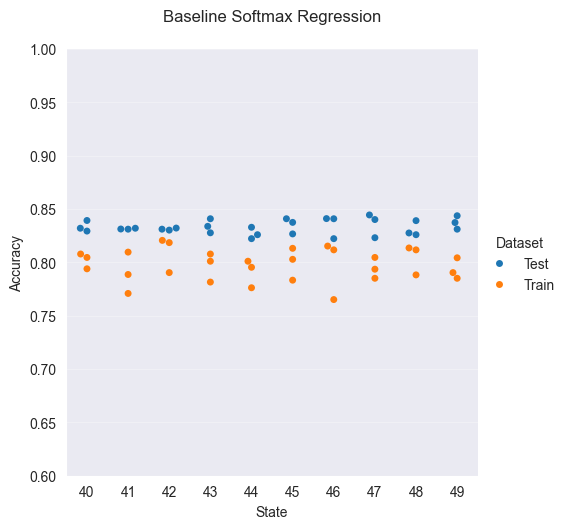


L2 Regularization

                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.98      0.87        56
      Normal_Weight       0.84      0.44      0.57        62
     Obesity_Type_I       0.83      0.77      0.80        78
    Obesity_Type_II       0.85      0.97      0.90        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.62      0.75      0.68        56
Overweight_Level_II       0.68      0.68      0.68        50

           accuracy                           0.80       423
          macro avg       0.80      0.80      0.78       423
       weighted avg       0.80      0.80      0.79       423



<Figure size 500x300 with 0 Axes>

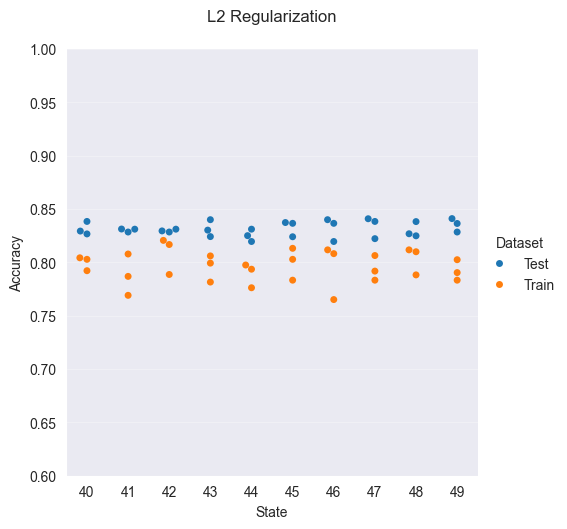


L1 Regularization

                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.98      0.87        56
      Normal_Weight       0.84      0.44      0.57        62
     Obesity_Type_I       0.83      0.77      0.80        78
    Obesity_Type_II       0.85      0.97      0.90        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.62      0.75      0.68        56
Overweight_Level_II       0.68      0.68      0.68        50

           accuracy                           0.80       423
          macro avg       0.80      0.80      0.78       423
       weighted avg       0.80      0.80      0.79       423



<Figure size 500x300 with 0 Axes>

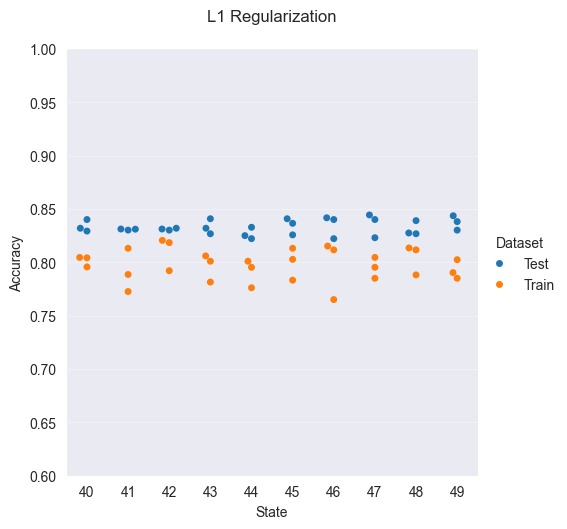


Elastic Net

                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.98      0.87        56
      Normal_Weight       0.84      0.44      0.57        62
     Obesity_Type_I       0.83      0.77      0.80        78
    Obesity_Type_II       0.85      0.97      0.90        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.62      0.75      0.68        56
Overweight_Level_II       0.68      0.68      0.68        50

           accuracy                           0.80       423
          macro avg       0.80      0.80      0.78       423
       weighted avg       0.80      0.80      0.79       423



<Figure size 500x300 with 0 Axes>

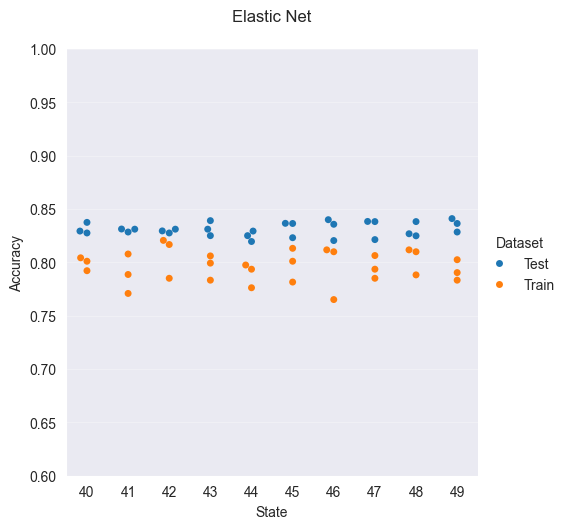


Grid Search

                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.98      0.87        56
      Normal_Weight       0.84      0.44      0.57        62
     Obesity_Type_I       0.83      0.77      0.80        78
    Obesity_Type_II       0.85      0.97      0.90        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.62      0.75      0.68        56
Overweight_Level_II       0.68      0.68      0.68        50

           accuracy                           0.80       423
          macro avg       0.80      0.80      0.78       423
       weighted avg       0.80      0.80      0.79       423



<Figure size 500x300 with 0 Axes>

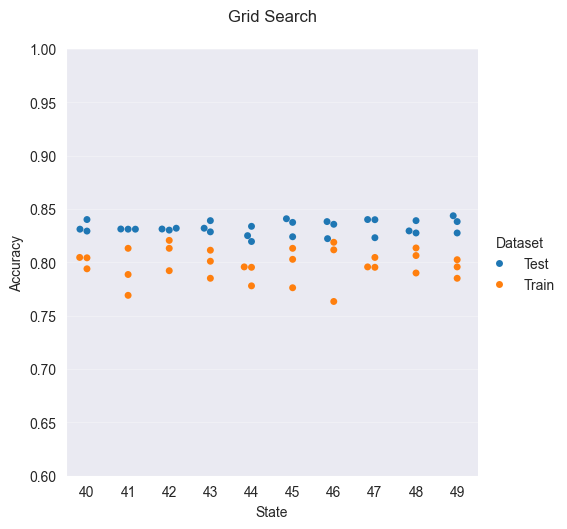


Polynomial Features

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.96      0.96        56
      Normal_Weight       0.69      0.69      0.69        62
     Obesity_Type_I       0.91      0.92      0.92        78
    Obesity_Type_II       0.97      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.71      0.62      0.67        56
Overweight_Level_II       0.78      0.84      0.81        50

           accuracy                           0.87       423
          macro avg       0.86      0.86      0.86       423
       weighted avg       0.86      0.87      0.86       423



<Figure size 500x300 with 0 Axes>

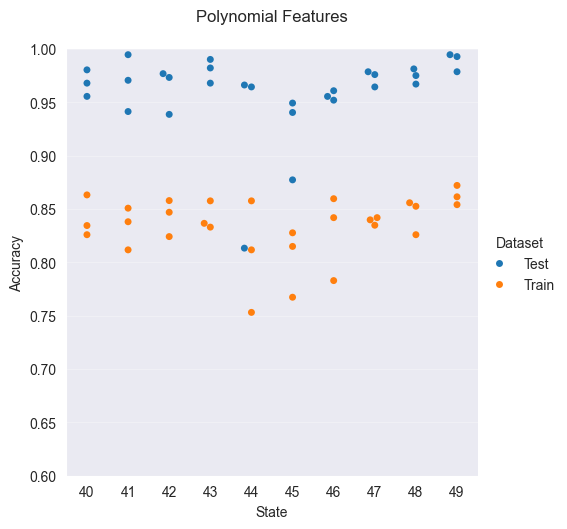


Polynomial Features + L1 + L2

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.96      0.96        56
      Normal_Weight       0.71      0.71      0.71        62
     Obesity_Type_I       0.90      0.94      0.92        78
    Obesity_Type_II       0.97      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.75      0.64      0.69        56
Overweight_Level_II       0.79      0.84      0.82        50

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423



<Figure size 500x300 with 0 Axes>

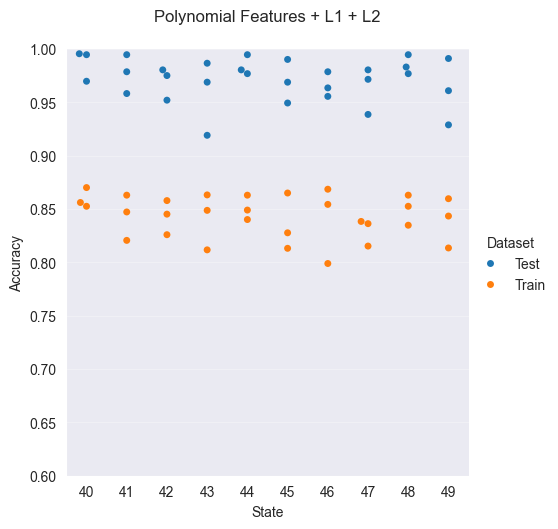


Polynomial Features + SMOTE

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.96      0.94        56
      Normal_Weight       0.66      0.63      0.64        62
     Obesity_Type_I       0.91      0.91      0.91        78
    Obesity_Type_II       0.97      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.70      0.66      0.68        56
Overweight_Level_II       0.81      0.84      0.82        50

           accuracy                           0.86       423
          macro avg       0.85      0.86      0.85       423
       weighted avg       0.86      0.86      0.86       423



<Figure size 500x300 with 0 Axes>

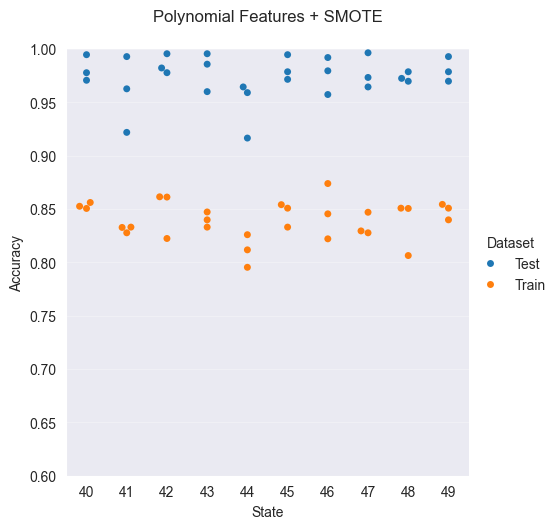


SMOTE Oversampling

                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.98      0.86        56
      Normal_Weight       0.83      0.47      0.60        62
     Obesity_Type_I       0.88      0.76      0.81        78
    Obesity_Type_II       0.84      0.97      0.90        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.66      0.75      0.70        56
Overweight_Level_II       0.69      0.74      0.71        50

           accuracy                           0.81       423
          macro avg       0.80      0.81      0.80       423
       weighted avg       0.81      0.81      0.80       423



<Figure size 500x300 with 0 Axes>

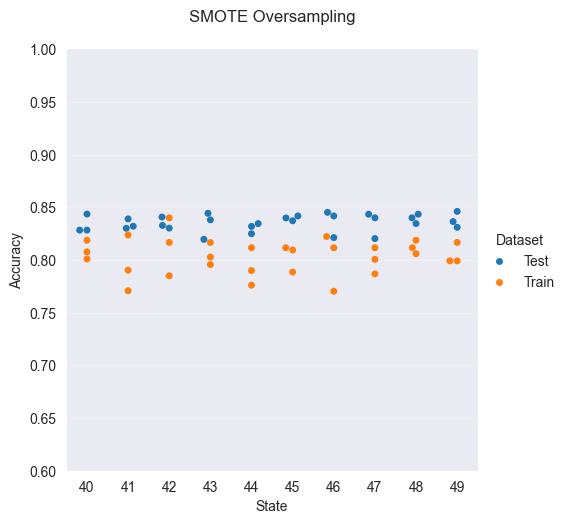


SMOTE + Grid Search

                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.98      0.86        56
      Normal_Weight       0.83      0.47      0.60        62
     Obesity_Type_I       0.88      0.76      0.81        78
    Obesity_Type_II       0.84      0.97      0.90        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.66      0.75      0.70        56
Overweight_Level_II       0.69      0.74      0.71        50

           accuracy                           0.81       423
          macro avg       0.80      0.81      0.80       423
       weighted avg       0.81      0.81      0.80       423



<Figure size 500x300 with 0 Axes>

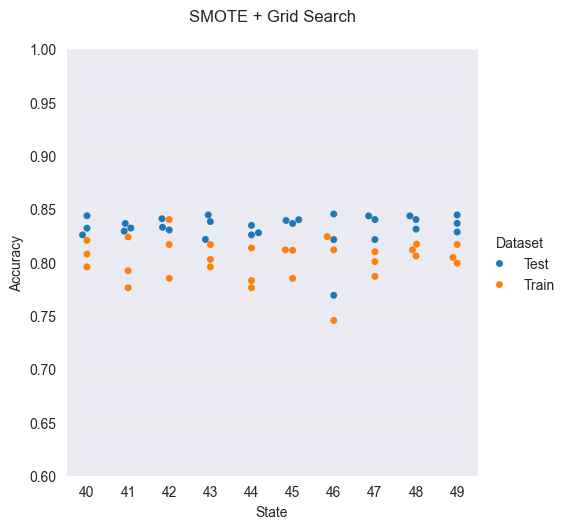

,Model,Accuracy
0,Polynomial Features + L1 + L2,0.872340
1,Polynomial Features,0.865248
2,Polynomial Features + SMOTE,0.858156
3,SMOTE Oversampling,0.806147
4,SMOTE + Grid Search,0.806147
5,Baseline Softmax Regression,0.796690
6,L2 Regularization,0.796690
7,Grid Search,0.796690
8,L1 Regularization,0.796690
9,Elastic Net,0.796690


In [37]:
ablation_results = []

def build_pipeline(preprocessor, classifier, poly=False, smote=False):
    steps = []
    steps.append(('preprocessor', preprocessor))
    if smote:
        steps.append(('smote', SMOTE(random_state=42)))
    if poly:
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=True)))
    steps.append(('classifier', classifier))
    return imbPipeline(steps) if smote else Pipeline(steps)


def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ablation_results.append({
        "Model": name,
        "Accuracy": acc
    })
    print(f"\n{name}\n")
    print(classification_report(y_test, y_pred))
    cross_vals(name, pipeline)


# 1. Baseline
evaluate_model("Baseline Softmax Regression",
               build_pipeline(preprocessor, SoftmaxRegression(max_iter=200)))

# 2. L2 Regularization
evaluate_model("L2 Regularization",
               build_pipeline(preprocessor, SoftmaxRegression(max_iter=200, regularization='l2', lambda_=0.1)))

# 3. L1 Regularization
evaluate_model("L1 Regularization",
               build_pipeline(preprocessor, SoftmaxRegression(max_iter=200, regularization='l1', lambda_=0.1)))

# 4. Elastic Net
evaluate_model("Elastic Net",
               build_pipeline(preprocessor, SoftmaxRegression(max_iter=200, regularization='both', lambda_=0.1)))

# 5. Grid Search
grid_model = build_pipeline(preprocessor, SoftmaxRegression(max_iter=200))
param_grid = {
    'classifier__learning_rate': [0.01, 0.001],
    'classifier__regularization': [None, 'l1', 'l2', 'both'],
    'classifier__lambda_': [0.1, 1, 10]
}
grid_search = GridSearchCV(grid_model, param_grid, scoring='accuracy', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
acc = accuracy_score(y_test, y_pred)
ablation_results.append({
    "Model": "Grid Search",
    "Accuracy": acc
})
print("\nGrid Search\n")
print(classification_report(y_test, y_pred))
cross_vals('Grid Search', grid_search)

# 6. Polynomial Features
evaluate_model("Polynomial Features",
               build_pipeline(preprocessor, SoftmaxRegression(max_iter=200), poly=True))

evaluate_model("Polynomial Features + L1 + L2",
               build_pipeline(preprocessor,
                              SoftmaxRegression(max_iter=200, regularization='both', lambda_=0.1), poly=True))

evaluate_model("Polynomial Features + SMOTE",
               build_pipeline(preprocessor,
                              SoftmaxRegression(max_iter=200), poly=True, smote=True))

# 7. SMOTE
evaluate_model("SMOTE Oversampling",
               build_pipeline(preprocessor, SoftmaxRegression(max_iter=200), smote=True))

# 8. SMOTE + Grid Search
grid_model_smote = build_pipeline(preprocessor, SoftmaxRegression(max_iter=200), smote=True)
grid_search_smote = GridSearchCV(grid_model_smote, param_grid, scoring='accuracy', cv=3, n_jobs=-1)
grid_search_smote.fit(X_train, y_train)
y_pred = grid_search_smote.predict(X_test)
acc = accuracy_score(y_test, y_pred)
ablation_results.append({
    "Model": "SMOTE + Grid Search",
    "Accuracy": acc
})
print("\nSMOTE + Grid Search\n")
print(classification_report(y_test, y_pred))
cross_vals('SMOTE + Grid Search', grid_search_smote)

ablation_df = pd.DataFrame(ablation_results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(ablation_df)


## Ablation Study Summary

The ablation study demonstrates how different optimization techniques affect the performance of a custom SoftmaxRegression model. Among the tested variants, adding polynomial features yielded the highest accuracies, highlighting the benefit of capturing nonlinear relationships between features. Both SMOTE oversampling and SMOTE combined with grid search improved the model's performanc, confirming that balancing the class distribution helps in better generalization for minority classes. Interestingly, regularization techniques (L1, L2, Elastic Net) and hyperparameter tuning via grid search showed no improvement over the baseline. This suggests that the base model was already well-regularized and appropriately configured. Overall, feature expansion and data balancing provided the most tangible gains, while regularization and tuning had neutral effects under current settings. Also, SMOTE on Polynomial Features seemed to **reduce** the accuracy of the model - this might be due to the synthetically created samples not alligning with the captured non-linear relationships between them.